# Alzheimer's Logistic Regression + LDA Notebook

This notebook is **self-contained** and compares **Logistic Regression** and **Linear Discriminant Analysis (LDA)** in the same file.

It mirrors the Random Forest notebook structure:

1. **Experiment A — Full feature set**
2. **Experiment B — Risk factors only** (symptom variables removed)

Outputs per model and experiment:
- train/test metrics
- 5-fold cross-validation
- confusion matrix
- ROC curve
- coefficient importance
- permutation importance
- direct **Logistic Regression vs LDA** comparison graphs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
print("Libraries loaded.")

Libraries loaded.


In [2]:
CSV_PATH = "data/alzheimers_disease_data.csv"

df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
display(df.head())

Shape: (2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [3]:
if "BMI" in df.columns and "BMI_category" not in df.columns:
    df["BMI_category"] = pd.cut(
        df["BMI"],
        bins=[0, 18.5, 25, 30, 100],
        labels=["Underweight", "Normal", "Overweight", "Obese"]
    )

drop_cols = [col for col in ["PatientID", "DoctorInCharge"] if col in df.columns]
df = df.drop(columns=drop_cols, errors="ignore")

TARGET = "Diagnosis"

SYMPTOM_COLS = [
    "MMSE", "ADL", "FunctionalAssessment",
    "MemoryComplaints", "BehavioralProblems", "DifficultyCompletingTasks"
]

print("Dropped:", drop_cols)
print("Target:", TARGET)
print("Symptom columns present:", [c for c in SYMPTOM_COLS if c in df.columns])
print("\nClass distribution:")
print(df[TARGET].value_counts())

Dropped: ['PatientID', 'DoctorInCharge']
Target: Diagnosis
Symptom columns present: ['MMSE', 'ADL', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'DifficultyCompletingTasks']

Class distribution:
Diagnosis
0    1389
1     760
Name: count, dtype: int64


In [4]:
def build_feature_lists(X):
    categorical = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    numeric = X.select_dtypes(include=[np.number]).columns.tolist()
    return numeric, categorical


def build_preprocessor(numeric, categorical):
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ])
    return ColumnTransformer([
        ("num", num_pipe, numeric),
        ("cat", cat_pipe, categorical)
    ])


def get_feature_names(fitted_pipeline, numeric, categorical):
    names = list(numeric)
    if categorical:
        ohe = (
            fitted_pipeline.named_steps["preprocessor"]
            .named_transformers_["cat"]
            .named_steps["onehot"]
        )
        names += ohe.get_feature_names_out(categorical).tolist()
    return names


def build_logistic_pipeline(numeric, categorical, model_params=None):
    if model_params is None:
        model_params = {}
    return Pipeline([
        ("preprocessor", build_preprocessor(numeric, categorical)),
        ("model", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            **model_params
        ))
    ])


def build_lda_pipeline(numeric, categorical, model_params=None):
    if model_params is None:
        model_params = {}
    return Pipeline([
        ("preprocessor", build_preprocessor(numeric, categorical)),
        ("model", LinearDiscriminantAnalysis(**model_params))
    ])


def _safe_predict_proba(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        scores = estimator.decision_function(X)
        return (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
    raise ValueError("Estimator has neither predict_proba nor decision_function.")


def _evaluate_model(df_input, target, experiment_name, model_name, builder, param_grid=None):
    X = df_input.drop(columns=[target])
    y = df_input[target]

    numeric, categorical = build_feature_lists(X)

    print(f"\n{'='*70}")
    print(f"{experiment_name} — {model_name}")
    print(f"{'='*70}")
    print("X shape:", X.shape)
    print("\nClass distribution:")
    print(y.value_counts())

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )

    best_params = {}
    if param_grid is not None:
        print("\nRunning GridSearchCV...")
        grid = GridSearchCV(
            builder(numeric, categorical),
            param_grid=param_grid,
            cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
            scoring="roc_auc",
            n_jobs=-1,
            verbose=0
        )
        grid.fit(X_train, y_train)
        best_params = {k.replace("model__", ""): v for k, v in grid.best_params_.items()}
        print("Best params:", best_params)
        print(f"Best CV AUC: {grid.best_score_:.4f}")

    pipeline = builder(numeric, categorical, best_params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    }
    cv_res = cross_validate(
        pipeline, X_train, y_train, cv=cv,
        scoring=scoring, return_train_score=False
    )
    cv_df = pd.DataFrame({m: cv_res[f"test_{m}"] for m in scoring})

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = _safe_predict_proba(pipeline, X_test)

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

    print("\nTest metrics:")
    display(pd.DataFrame([metrics]).round(4))

    print("\n5-fold CV mean:")
    display(cv_df.mean().to_frame("Mean").T.round(4))

    print("\n5-fold CV std:")
    display(cv_df.std().to_frame("Std").T.round(4))

    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion matrix:")
    print(cm)

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    feat_names = get_feature_names(pipeline, numeric, categorical)
    model = pipeline.named_steps["model"]

    if hasattr(model, "coef_"):
        coef_values = np.ravel(model.coef_)
        coef_df = pd.DataFrame({
            "Feature": feat_names,
            "Coefficient": coef_values,
            "AbsCoefficient": np.abs(coef_values)
        }).sort_values("AbsCoefficient", ascending=False)
    else:
        coef_df = pd.DataFrame(columns=["Feature", "Coefficient", "AbsCoefficient"])

    print("\nTop 15 coefficients by absolute value:")
    display(coef_df.head(15))

    perm = permutation_importance(
        pipeline, X_test, y_test,
        n_repeats=20, random_state=RANDOM_STATE,
        scoring="roc_auc", n_jobs=-1
    )
    perm_df = pd.DataFrame({
        "Feature": X_test.columns,
        "Perm_Mean": perm.importances_mean,
        "Perm_Std": perm.importances_std
    }).sort_values("Perm_Mean", ascending=False)

    print("\nTop 15 permutation importances:")
    display(perm_df.head(15))

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["No", "Yes"]
    ).plot(ax=axes[0], colorbar=False, cmap="Blues")
    axes[0].set_title(f"{model_name}\nConfusion Matrix")

    RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name=model_name)
    axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
    axes[1].set_title(f"{model_name}\nROC Curve")

    top15 = coef_df.head(15).sort_values("Coefficient")
    colors = np.where(top15["Coefficient"] >= 0, "tab:blue", "tab:orange")
    axes[2].barh(top15["Feature"], top15["Coefficient"], color=colors, alpha=0.85)
    axes[2].axvline(0, color="black", linewidth=0.8, linestyle="--")
    axes[2].set_title(f"{model_name}\nTop 15 Coefficients")
    axes[2].set_xlabel("Coefficient value")
    axes[2].grid(axis="x", alpha=0.3)

    plt.suptitle(f"{experiment_name} — {model_name}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    return {
        "model_name": model_name,
        "experiment_name": experiment_name,
        "pipeline": pipeline,
        "cv_df": cv_df,
        "metrics": metrics,
        "coef_df": coef_df,
        "perm_df": perm_df
    }


def evaluate_logistic(df_input, target, experiment_name, tune=True):
    param_grid = None
    if tune:
        param_grid = {
            "model__C": [0.01, 0.1, 1, 10],
            "model__solver": ["liblinear", "lbfgs"]
        }
    return _evaluate_model(
        df_input=df_input,
        target=target,
        experiment_name=experiment_name,
        model_name="Logistic Regression",
        builder=build_logistic_pipeline,
        param_grid=param_grid
    )


def evaluate_lda(df_input, target, experiment_name, tune=True):
    param_grid = None
    if tune:
        param_grid = [
            {"model__solver": ["svd"]},
            {"model__solver": ["lsqr"], "model__shrinkage": [None, "auto"]}
        ]
    return _evaluate_model(
        df_input=df_input,
        target=target,
        experiment_name=experiment_name,
        model_name="LDA",
        builder=build_lda_pipeline,
        param_grid=param_grid
    )


def build_comparison_df(results_list, experiment_label):
    rows = []
    for results in results_list:
        row = {"Model": results["model_name"], "Experiment": experiment_label}
        row.update(results["metrics"])
        rows.append(row)
    return pd.DataFrame(rows)


def plot_metric_comparison(comparison_df, title):
    metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
    plot_df = comparison_df.set_index("Model")[metrics].T

    ax = plot_df.plot(kind="bar", figsize=(10, 6))
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Score")
    ax.set_xlabel("Metric")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=0)
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()


def plot_perm_side_by_side(results_left, results_right, title_left, title_right, suptitle):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    for ax, results, title in zip(
        axes,
        [results_left, results_right],
        [title_left, title_right]
    ):
        top15 = results["perm_df"].head(15).sort_values("Perm_Mean")
        ax.barh(
            top15["Feature"], top15["Perm_Mean"],
            xerr=top15["Perm_Std"], alpha=0.85,
            error_kw={"elinewidth": 1.2, "capsize": 3}
        )
        ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Permutation importance (drop in ROC-AUC)")
        ax.grid(axis="x", alpha=0.3)

    plt.suptitle(suptitle, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

## Experiment A — Full Feature Set


Experiment A - Full Feature Set — Logistic Regression
X shape: (2149, 33)

Class distribution:
Diagnosis
0    1389
1     760
Name: count, dtype: int64

Running GridSearchCV...
Best params: {'C': 0.01, 'solver': 'lbfgs'}
Best CV AUC: 0.9035

Test metrics:


,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.8093,0.6842,0.8553,0.7602,0.8829



5-fold CV mean:


,accuracy,precision,recall,f1,roc_auc
Mean,0.8255,0.72,0.8355,0.7725,0.904



5-fold CV std:


,accuracy,precision,recall,f1,roc_auc
Std,0.0202,0.0398,0.0232,0.0178,0.0166



Confusion matrix:
[[218  60]
 [ 22 130]]

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       278
           1       0.68      0.86      0.76       152

    accuracy                           0.81       430
   macro avg       0.80      0.82      0.80       430
weighted avg       0.83      0.81      0.81       430


Top 15 coefficients by absolute value:


,Feature,Coefficient,AbsCoefficient
23,FunctionalAssessment,-0.717177,0.717177
26,ADL,-0.685195,0.685195
24,MemoryComplaints,0.644391,0.644391
25,BehavioralProblems,0.489255,0.489255
22,MMSE,-0.450667,0.450667
20,CholesterolHDL,0.086582,0.086582
9,SleepQuality,-0.072539,0.072539
0,Age,-0.071576,0.071576
19,CholesterolLDL,-0.069679,0.069679
21,CholesterolTriglycerides,0.068747,0.068747



Top 15 permutation importances:


,Feature,Perm_Mean,Perm_Std
23,FunctionalAssessment,0.114740,0.013545
26,ADL,0.093419,0.013171
25,BehavioralProblems,0.060593,0.009971
24,MemoryComplaints,0.055864,0.011434
22,MMSE,0.047353,0.007260
19,CholesterolLDL,0.000446,0.001051
5,Smoking,0.000443,0.000456
13,Depression,0.000347,0.000291
14,HeadInjury,0.000266,0.001225
28,Disorientation,0.000235,0.000279


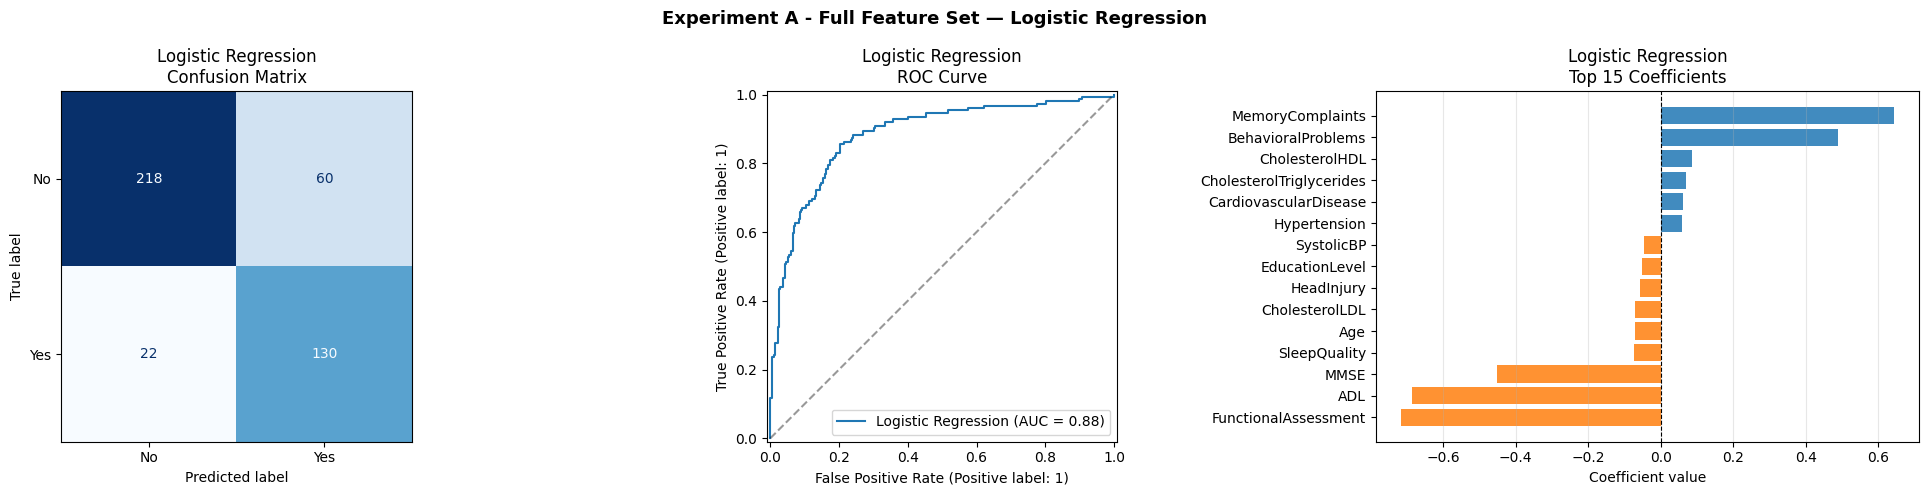


Experiment A - Full Feature Set — LDA
X shape: (2149, 33)

Class distribution:
Diagnosis
0    1389
1     760
Name: count, dtype: int64

Running GridSearchCV...
Best params: {'shrinkage': 'auto', 'solver': 'lsqr'}
Best CV AUC: 0.9027

Test metrics:


,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.814,0.7571,0.6974,0.726,0.8835



5-fold CV mean:


,accuracy,precision,recall,f1,roc_auc
Mean,0.8453,0.8186,0.7268,0.7684,0.9036



5-fold CV std:


,accuracy,precision,recall,f1,roc_auc
Std,0.0132,0.0415,0.0457,0.0205,0.015



Confusion matrix:
[[244  34]
 [ 46 106]]

Classification report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       278
           1       0.76      0.70      0.73       152

    accuracy                           0.81       430
   macro avg       0.80      0.79      0.79       430
weighted avg       0.81      0.81      0.81       430


Top 15 coefficients by absolute value:


,Feature,Coefficient,AbsCoefficient
23,FunctionalAssessment,-1.079962,1.079962
26,ADL,-1.012988,1.012988
24,MemoryComplaints,0.991662,0.991662
22,MMSE,-0.707068,0.707068
25,BehavioralProblems,0.689621,0.689621
34,BMI_category_Underweight,-0.174179,0.174179
20,CholesterolHDL,0.120687,0.120687
9,SleepQuality,-0.115288,0.115288
21,CholesterolTriglycerides,0.108643,0.108643
0,Age,-0.100427,0.100427



Top 15 permutation importances:


,Feature,Perm_Mean,Perm_Std
23,FunctionalAssessment,0.116798,0.013582
26,ADL,0.092787,0.013125
24,MemoryComplaints,0.057939,0.011775
25,BehavioralProblems,0.057858,0.009471
22,MMSE,0.050054,0.007756
19,CholesterolLDL,0.000898,0.000995
5,Smoking,0.000692,0.000364
28,Disorientation,0.000666,0.000381
2,Ethnicity,0.000525,0.000380
27,Confusion,0.000438,0.000348


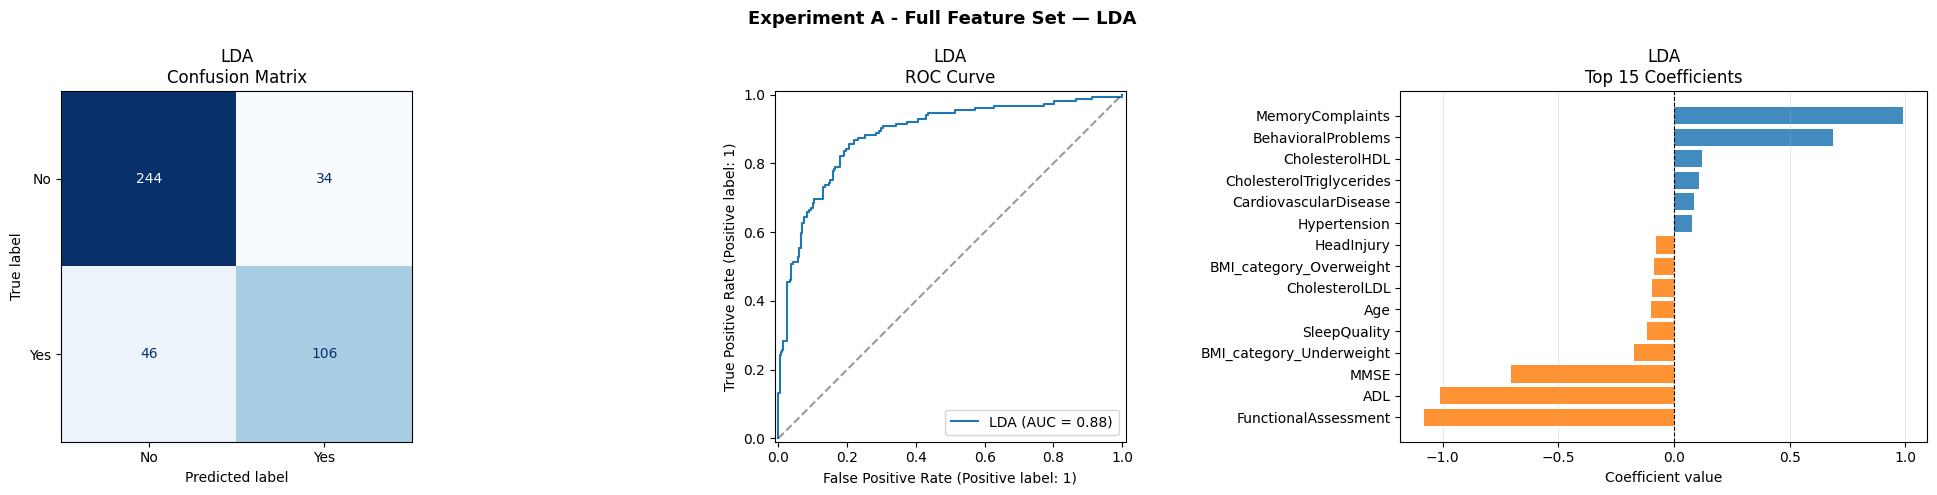

In [5]:
results_lr_full = evaluate_logistic(
    df_input=df.copy(),
    target=TARGET,
    experiment_name="Experiment A - Full Feature Set",
    tune=True
)

results_lda_full = evaluate_lda(
    df_input=df.copy(),
    target=TARGET,
    experiment_name="Experiment A - Full Feature Set",
    tune=True
)

Experiment A comparison:


,Model,Experiment,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,Full Feature Set,0.8093,0.6842,0.8553,0.7602,0.8829
1,LDA,Full Feature Set,0.8140,0.7571,0.6974,0.7260,0.8835


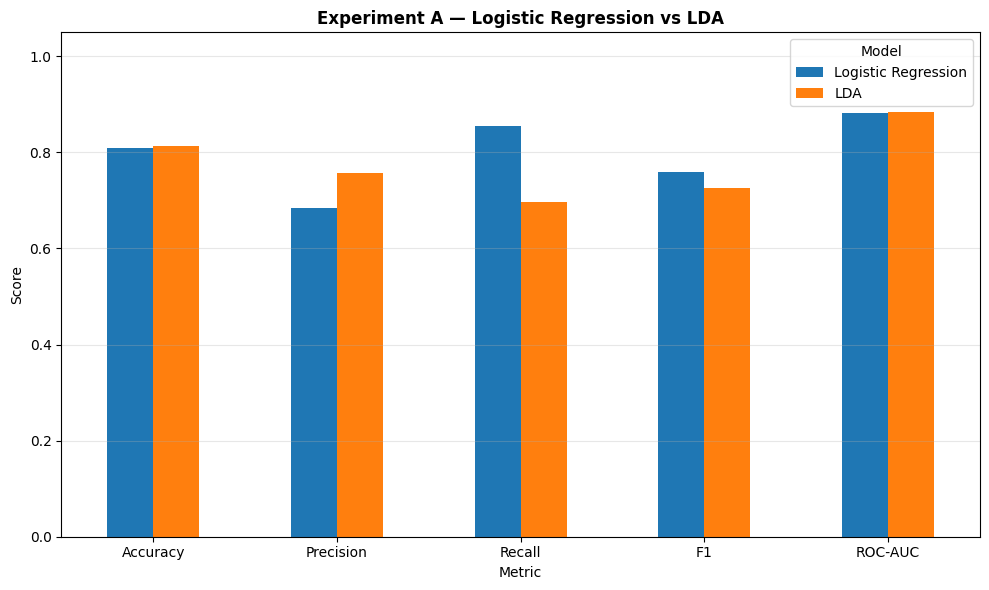

In [6]:
comparison_full = build_comparison_df(
    [results_lr_full, results_lda_full],
    experiment_label="Full Feature Set"
)

print("Experiment A comparison:")
display(comparison_full.round(4))

plot_metric_comparison(
    comparison_full,
    "Experiment A — Logistic Regression vs LDA"
)

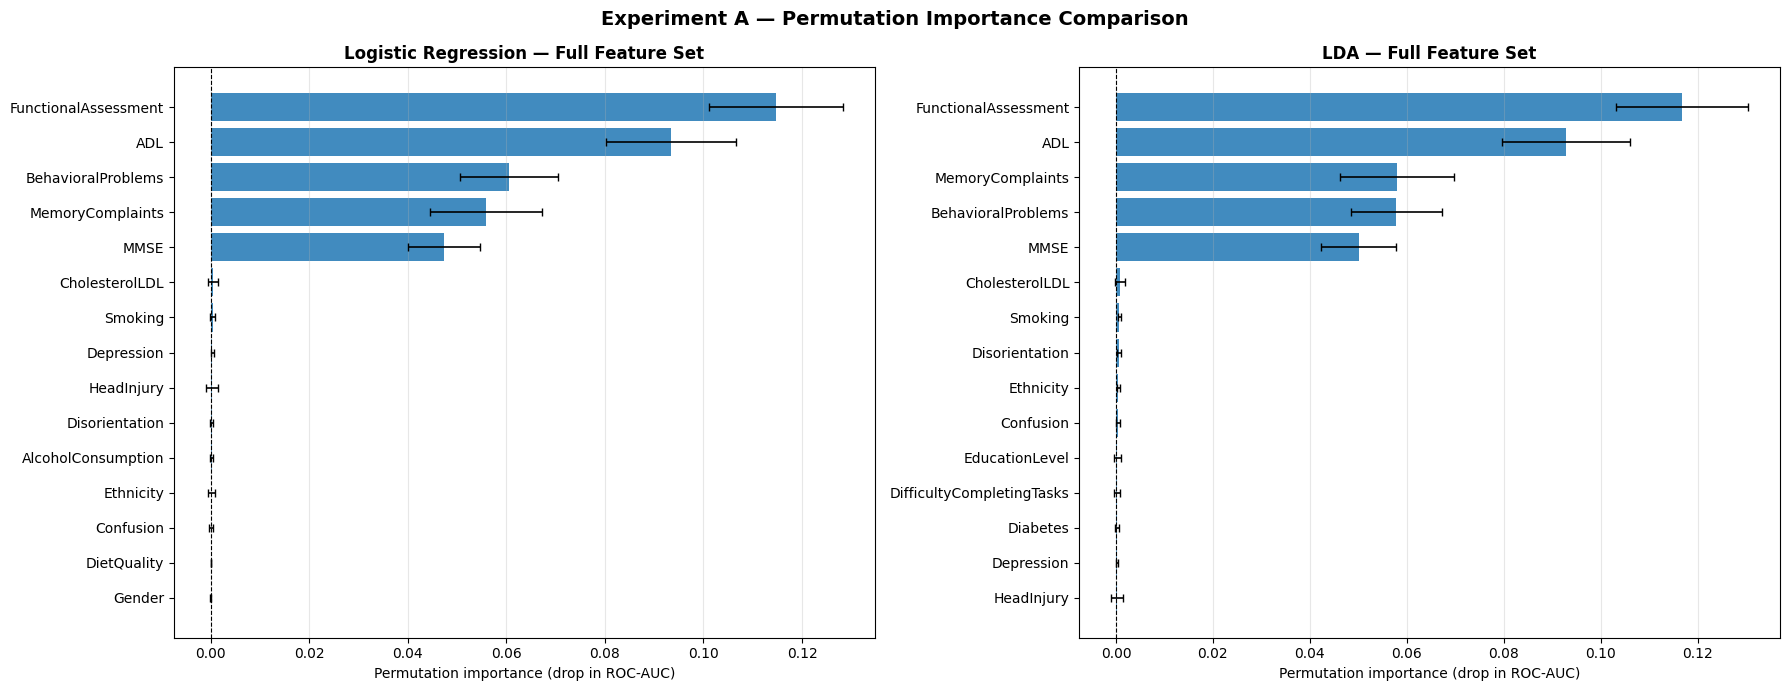

In [7]:
plot_perm_side_by_side(
    results_lr_full,
    results_lda_full,
    "Logistic Regression — Full Feature Set",
    "LDA — Full Feature Set",
    "Experiment A — Permutation Importance Comparison"
)

## Experiment B — Risk Factors Only

Removed: `MMSE`, `ADL`, `FunctionalAssessment`, `MemoryComplaints`, `BehavioralProblems`, `DifficultyCompletingTasks`


Experiment B - Risk Factors Only — Logistic Regression
X shape: (2149, 27)

Class distribution:
Diagnosis
0    1389
1     760
Name: count, dtype: int64

Running GridSearchCV...
Best params: {'C': 0.01, 'solver': 'lbfgs'}
Best CV AUC: 0.5419

Test metrics:


,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.5093,0.3589,0.4934,0.4155,0.5181



5-fold CV mean:


,accuracy,precision,recall,f1,roc_auc
Mean,0.5288,0.3779,0.5149,0.4357,0.534



5-fold CV std:


,accuracy,precision,recall,f1,roc_auc
Std,0.0122,0.0118,0.0334,0.0187,0.0144



Confusion matrix:
[[144 134]
 [ 77  75]]

Classification report:
              precision    recall  f1-score   support

           0       0.65      0.52      0.58       278
           1       0.36      0.49      0.42       152

    accuracy                           0.51       430
   macro avg       0.51      0.51      0.50       430
weighted avg       0.55      0.51      0.52       430


Top 15 coefficients by absolute value:


,Feature,Coefficient,AbsCoefficient
9,SleepQuality,-0.094516,0.094516
20,CholesterolHDL,0.089276,0.089276
16,SystolicBP,-0.078594,0.078594
11,CardiovascularDisease,0.075258,0.075258
24,PersonalityChanges,-0.066656,0.066656
21,CholesterolTriglycerides,0.064748,0.064748
3,EducationLevel,-0.061173,0.061173
12,Diabetes,-0.060640,0.060640
15,Hypertension,0.056819,0.056819
14,HeadInjury,-0.054766,0.054766



Top 15 permutation importances:


,Feature,Perm_Mean,Perm_Std
9,SleepQuality,0.016617,0.011191
3,EducationLevel,0.011065,0.008560
15,Hypertension,0.007252,0.007373
12,Diabetes,0.006113,0.009163
26,BMI_category,0.003776,0.004382
19,CholesterolLDL,0.002610,0.003842
22,Confusion,0.002104,0.002511
1,Gender,0.002023,0.002431
4,BMI,0.001684,0.003207
23,Disorientation,0.001494,0.003449


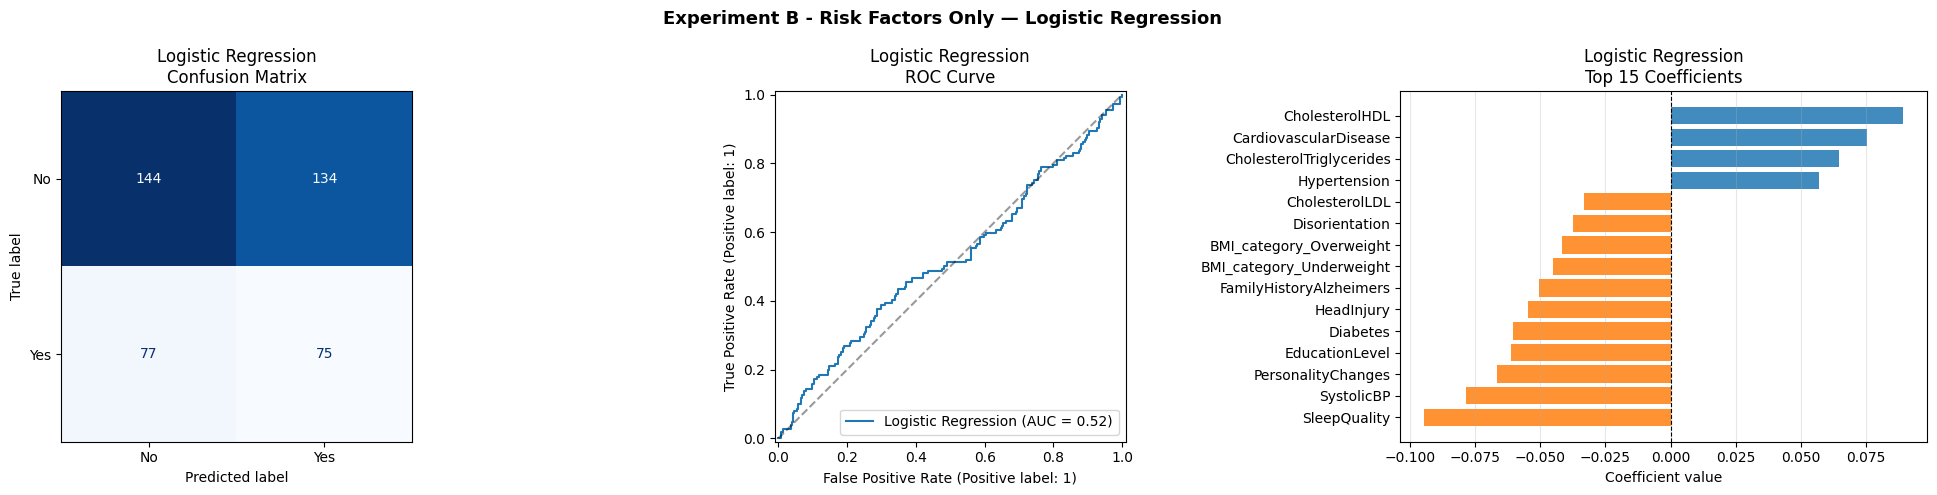


Experiment B - Risk Factors Only — LDA
X shape: (2149, 27)

Class distribution:
Diagnosis
0    1389
1     760
Name: count, dtype: int64

Running GridSearchCV...
Best params: {'shrinkage': 'auto', 'solver': 'lsqr'}
Best CV AUC: 0.5424

Test metrics:


,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.6442,0.4,0.0132,0.0255,0.5194



5-fold CV mean:


,accuracy,precision,recall,f1,roc_auc
Mean,0.6399,0.3939,0.0378,0.0683,0.5353



5-fold CV std:


,accuracy,precision,recall,f1,roc_auc
Std,0.0133,0.2049,0.0245,0.0434,0.0175



Confusion matrix:
[[275   3]
 [150   2]]

Classification report:
              precision    recall  f1-score   support

           0       0.65      0.99      0.78       278
           1       0.40      0.01      0.03       152

    accuracy                           0.64       430
   macro avg       0.52      0.50      0.40       430
weighted avg       0.56      0.64      0.51       430


Top 15 coefficients by absolute value:


,Feature,Coefficient,AbsCoefficient
28,BMI_category_Underweight,-0.174518,0.174518
9,SleepQuality,-0.118523,0.118523
20,CholesterolHDL,0.112314,0.112314
27,BMI_category_Overweight,-0.101672,0.101672
11,CardiovascularDisease,0.095664,0.095664
16,SystolicBP,-0.094770,0.094770
24,PersonalityChanges,-0.085568,0.085568
21,CholesterolTriglycerides,0.080336,0.080336
12,Diabetes,-0.075395,0.075395
3,EducationLevel,-0.072613,0.072613



Top 15 permutation importances:


,Feature,Perm_Mean,Perm_Std
9,SleepQuality,0.016116,0.011238
3,EducationLevel,0.010031,0.007837
26,BMI_category,0.007216,0.008660
12,Diabetes,0.006801,0.008991
15,Hypertension,0.006794,0.007001
22,Confusion,0.002111,0.002330
20,CholesterolHDL,0.001515,0.013071
10,FamilyHistoryAlzheimers,0.001315,0.006097
8,DietQuality,0.001270,0.000868
2,Ethnicity,0.001223,0.002728


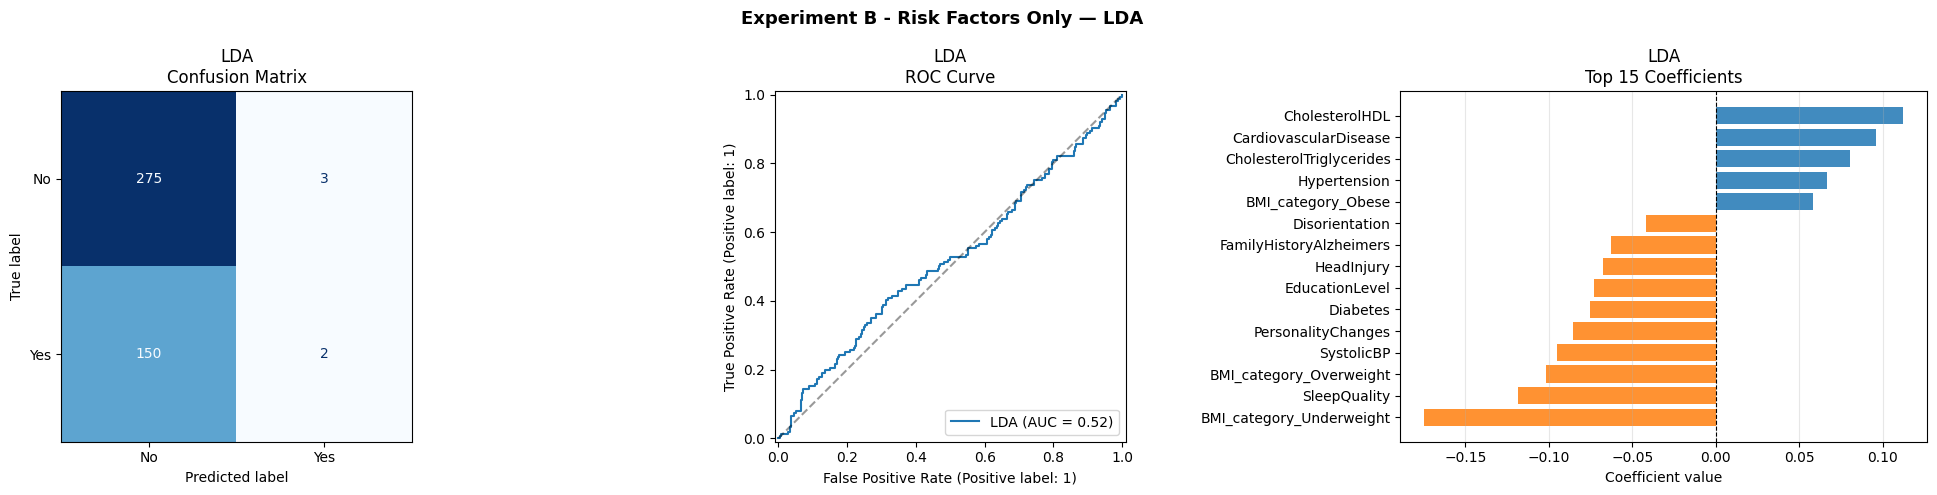

In [8]:
df_risk = df.drop(columns=SYMPTOM_COLS, errors="ignore").copy()

results_lr_risk = evaluate_logistic(
    df_input=df_risk,
    target=TARGET,
    experiment_name="Experiment B - Risk Factors Only",
    tune=True
)

results_lda_risk = evaluate_lda(
    df_input=df_risk,
    target=TARGET,
    experiment_name="Experiment B - Risk Factors Only",
    tune=True
)

Experiment B comparison:


,Model,Experiment,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,Risk Factors Only,0.5093,0.3589,0.4934,0.4155,0.5181
1,LDA,Risk Factors Only,0.6442,0.4000,0.0132,0.0255,0.5194


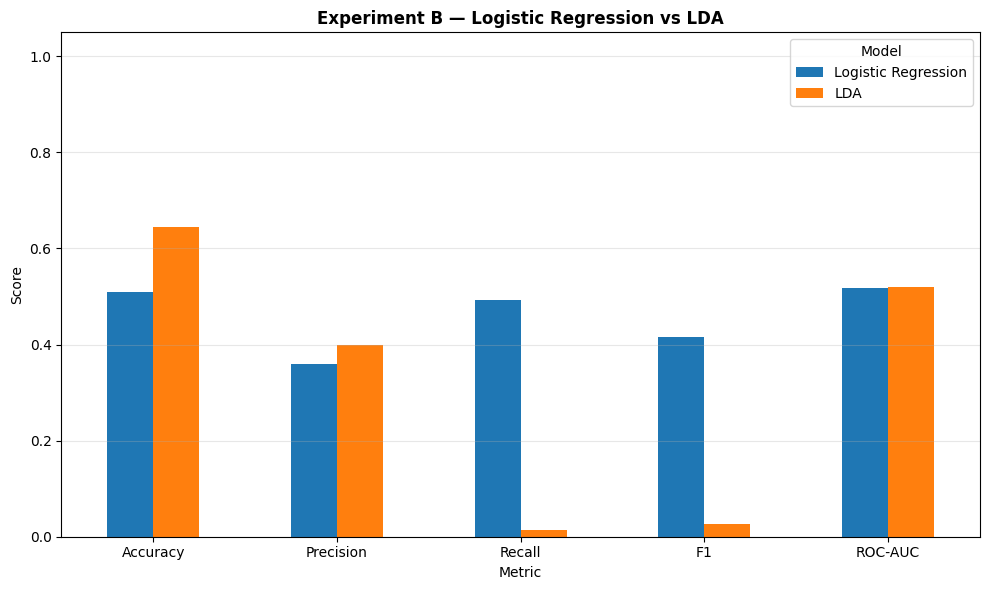

In [9]:
comparison_risk = build_comparison_df(
    [results_lr_risk, results_lda_risk],
    experiment_label="Risk Factors Only"
)

print("Experiment B comparison:")
display(comparison_risk.round(4))

plot_metric_comparison(
    comparison_risk,
    "Experiment B — Logistic Regression vs LDA"
)

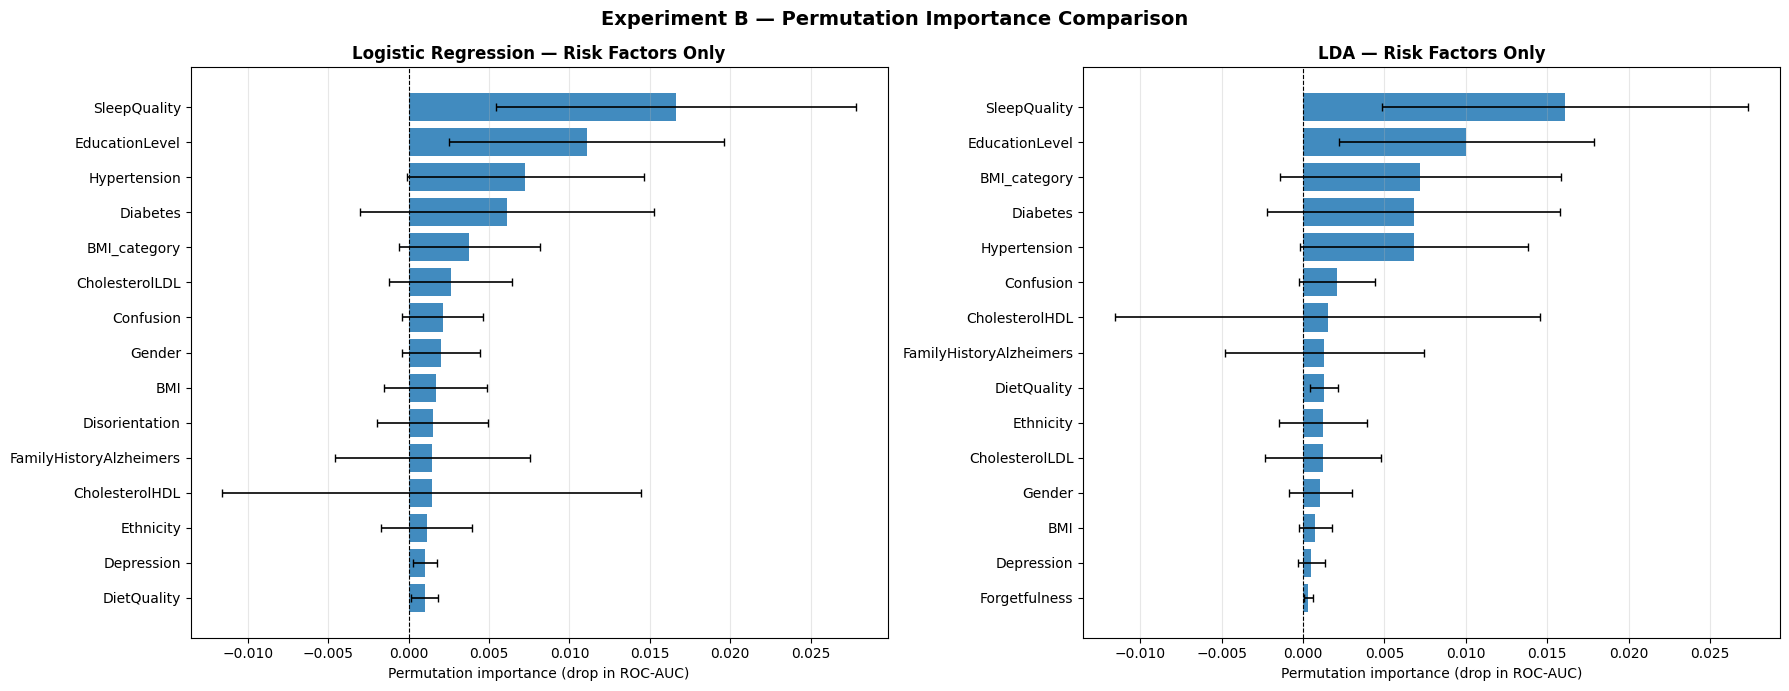

In [10]:
plot_perm_side_by_side(
    results_lr_risk,
    results_lda_risk,
    "Logistic Regression — Risk Factors Only",
    "LDA — Risk Factors Only",
    "Experiment B — Permutation Importance Comparison"
)

## Combined Comparison Across Both Experiments

,Model,Experiment,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,Full Feature Set,0.8093,0.6842,0.8553,0.7602,0.8829
1,LDA,Full Feature Set,0.8140,0.7571,0.6974,0.7260,0.8835
2,Logistic Regression,Risk Factors Only,0.5093,0.3589,0.4934,0.4155,0.5181
3,LDA,Risk Factors Only,0.6442,0.4000,0.0132,0.0255,0.5194


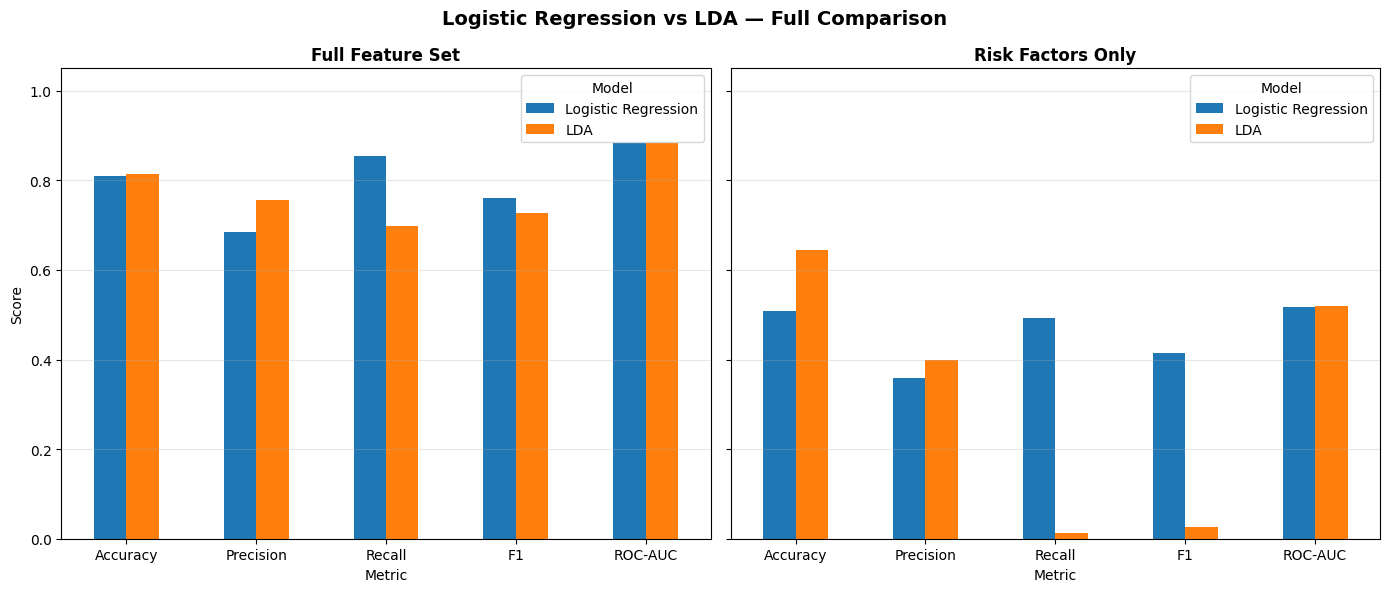

In [11]:
comparison_all = pd.concat([comparison_full, comparison_risk], ignore_index=True)
display(comparison_all.round(4))

metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
experiments = comparison_all["Experiment"].unique()

fig, axes = plt.subplots(1, len(experiments), figsize=(7 * len(experiments), 6), sharey=True)
if len(experiments) == 1:
    axes = [axes]

for ax, exp in zip(axes, experiments):
    subset = comparison_all[comparison_all["Experiment"] == exp].set_index("Model")[metrics].T
    subset.plot(kind="bar", ax=ax)
    ax.set_title(exp, fontweight="bold")
    ax.set_xlabel("Metric")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("Logistic Regression vs LDA — Full Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Interpretation Guide

### Logistic Regression vs LDA
- **Logistic Regression** directly models the probability of the class.
- **LDA** models class distributions and then derives a decision boundary.

### Coefficients
- Positive coefficient = pushes prediction more toward diagnosis = 1.
- Negative coefficient = pushes prediction more toward diagnosis = 0.
- Larger absolute value = stronger linear effect.

### Permutation Importance
- Measures how much performance drops when a feature is shuffled.
- Higher value = the model depends more on that feature.
- Near zero = the feature contributes little to that model on the test set.

### Why compare both?
These are both **linear classifiers**, so if Random Forest later performs much better, that suggests the dataset likely contains **non-linear relationships or interactions** that linear models do not capture well.